# Premium Product Analysis

Premium = Unit Price USD > $921.50 (IQR upper bound — 200 products, 7.95% of catalogue)

Source: sales_clean.parquet, products_clean.parquet, customers_clean.parquet

### Imports


In [1]:
import pandas as pd
from src.analysis import premium as pm
from src.viz import base

### Load Data

In [2]:
sales     = pd.read_parquet("../data/processed/sales_clean.parquet")
customers = pd.read_parquet("../data/processed/customers_clean.parquet")
products  = pd.read_parquet("../data/processed/products_clean.parquet")

print("sales   :", sales.shape)
print("customers:", customers.shape)
print("products :", products.shape)

sales   : (62884, 19)
customers: (15266, 12)
products : (2517, 13)


## Premium vs Standard — Orders and Revenue

,Category,Revenue USD
1,Computers,5606233.36
2,Home Appliances,5333621.89
3,TV and Video,3433193.50
0,Cameras and camcorders,1807125.30


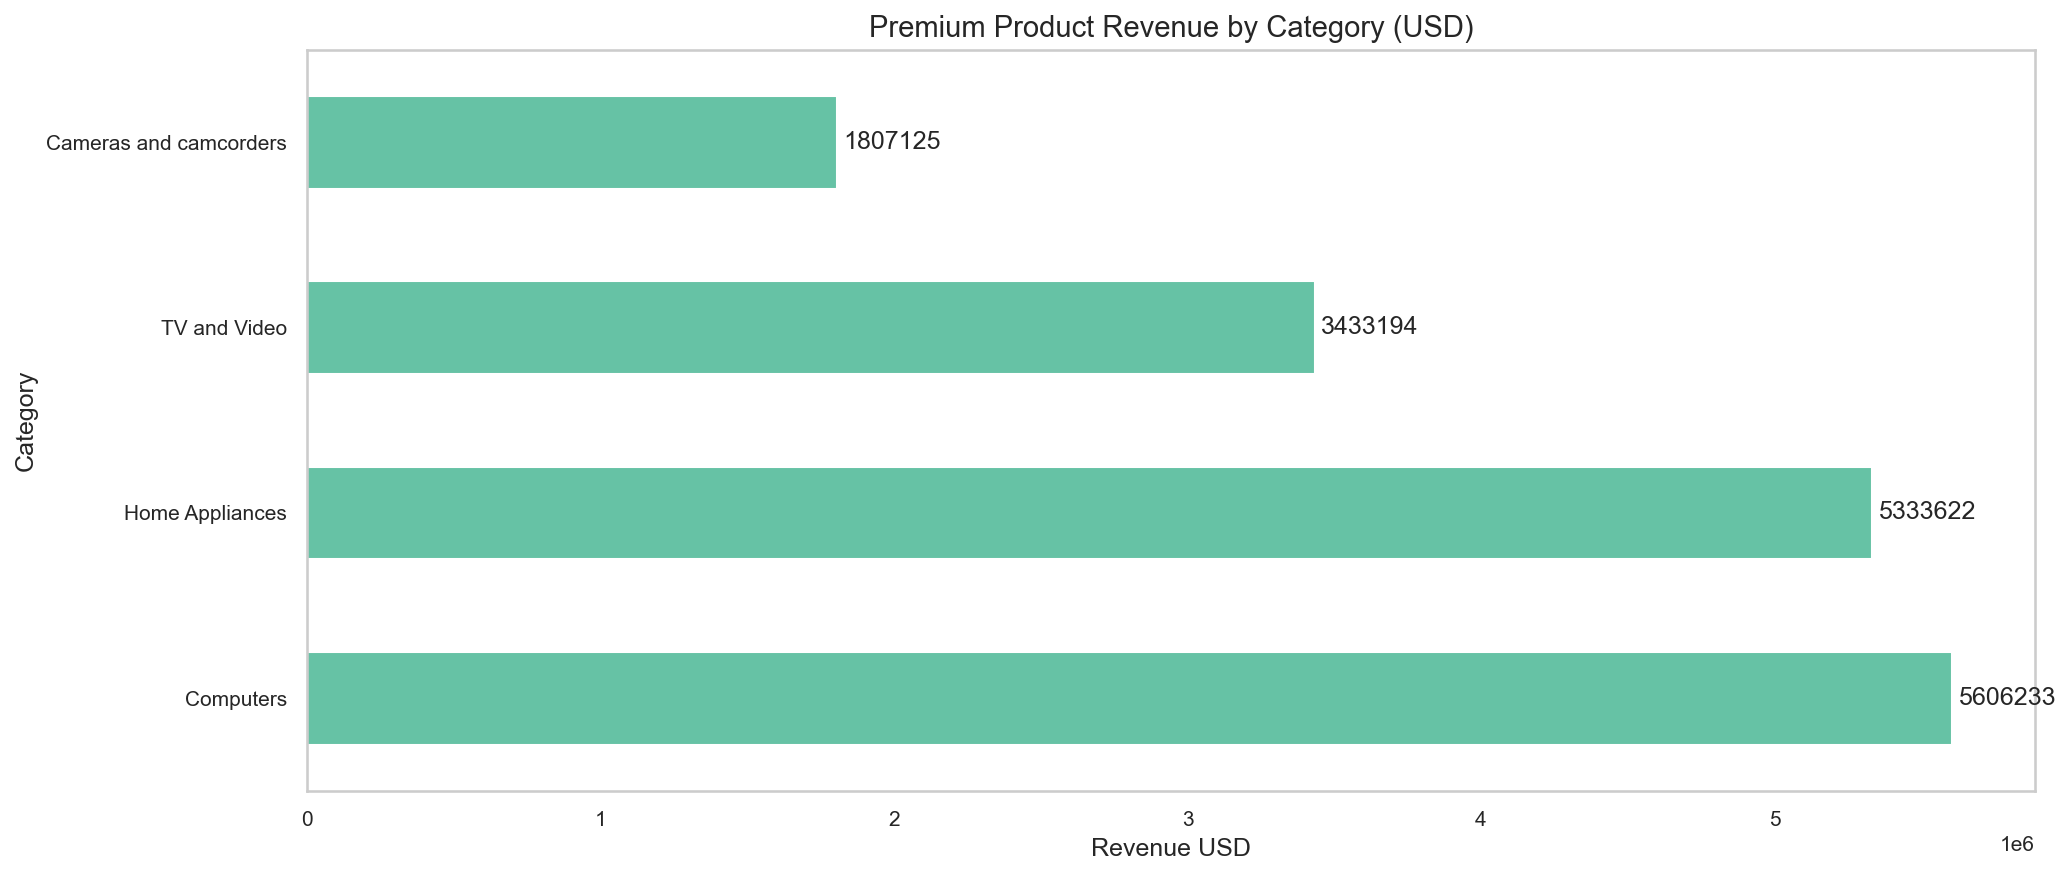

In [3]:
by_cat = pm.premium_revenue_by_category(sales, products)
display(by_cat)
fig, ax = base.horizontal_bar(
    by_cat.set_index("Category")["Revenue USD"],
    title="Premium Product Revenue by Category (USD)",
    xlabel="Revenue USD", ylabel="Category",
    filename="premium_by_category.png"
)

display(fig)

## Premium Revenue by Country

,Country,Revenue USD
7,United States,8273055.51
6,United Kingdom,2614686.53
3,Germany,1833821.55
1,Canada,1007891.08
4,Italy,809729.38
0,Australia,621390.43
5,Netherlands,548722.36
2,France,470877.21


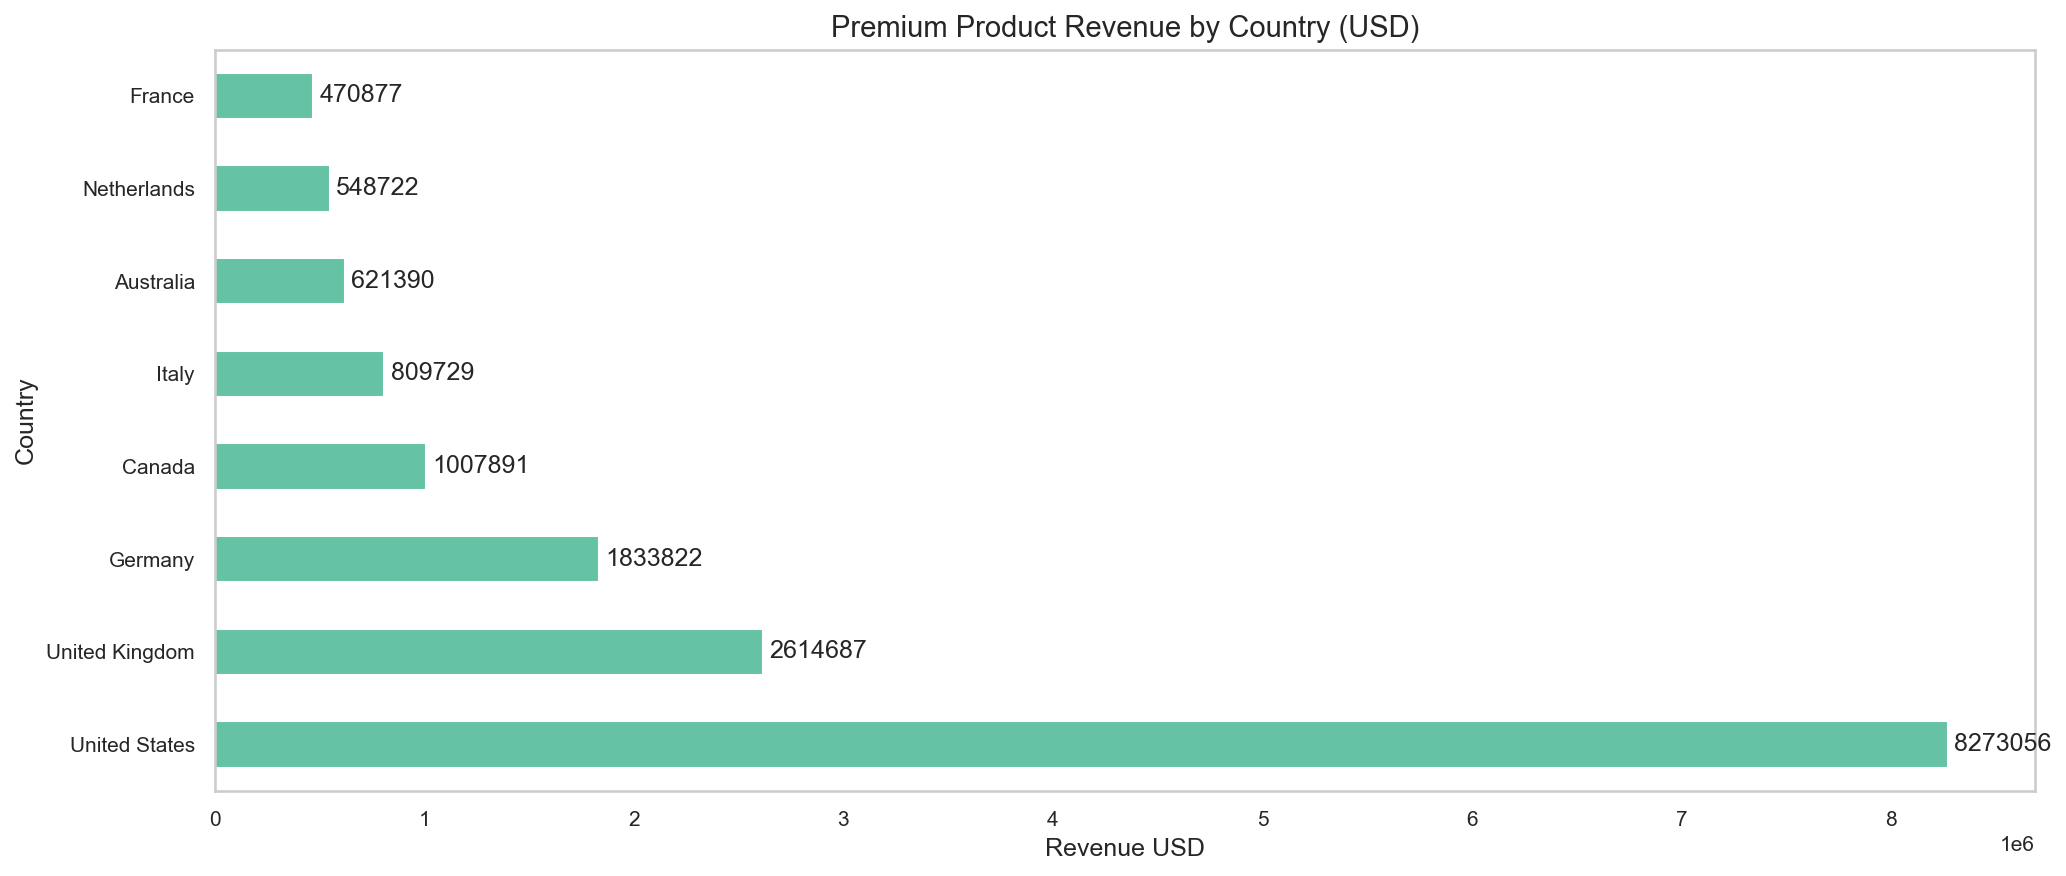

In [4]:
by_country = pm.premium_revenue_by_country(sales, products, customers)
display(by_country)
fig, ax = base.horizontal_bar(
    by_country.set_index("Country")["Revenue USD"],
    title="Premium Product Revenue by Country (USD)",
    xlabel="Revenue USD", ylabel="Country",
    filename="premium_by_country.png"
)

display(fig)

## Premium Revenue by Age Group

,Age Group,Revenue USD
4,65+,6219994.82
2,35-49,3832549.15
3,50-64,3457992.17
1,25-34,2423447.59
0,<25,246190.32


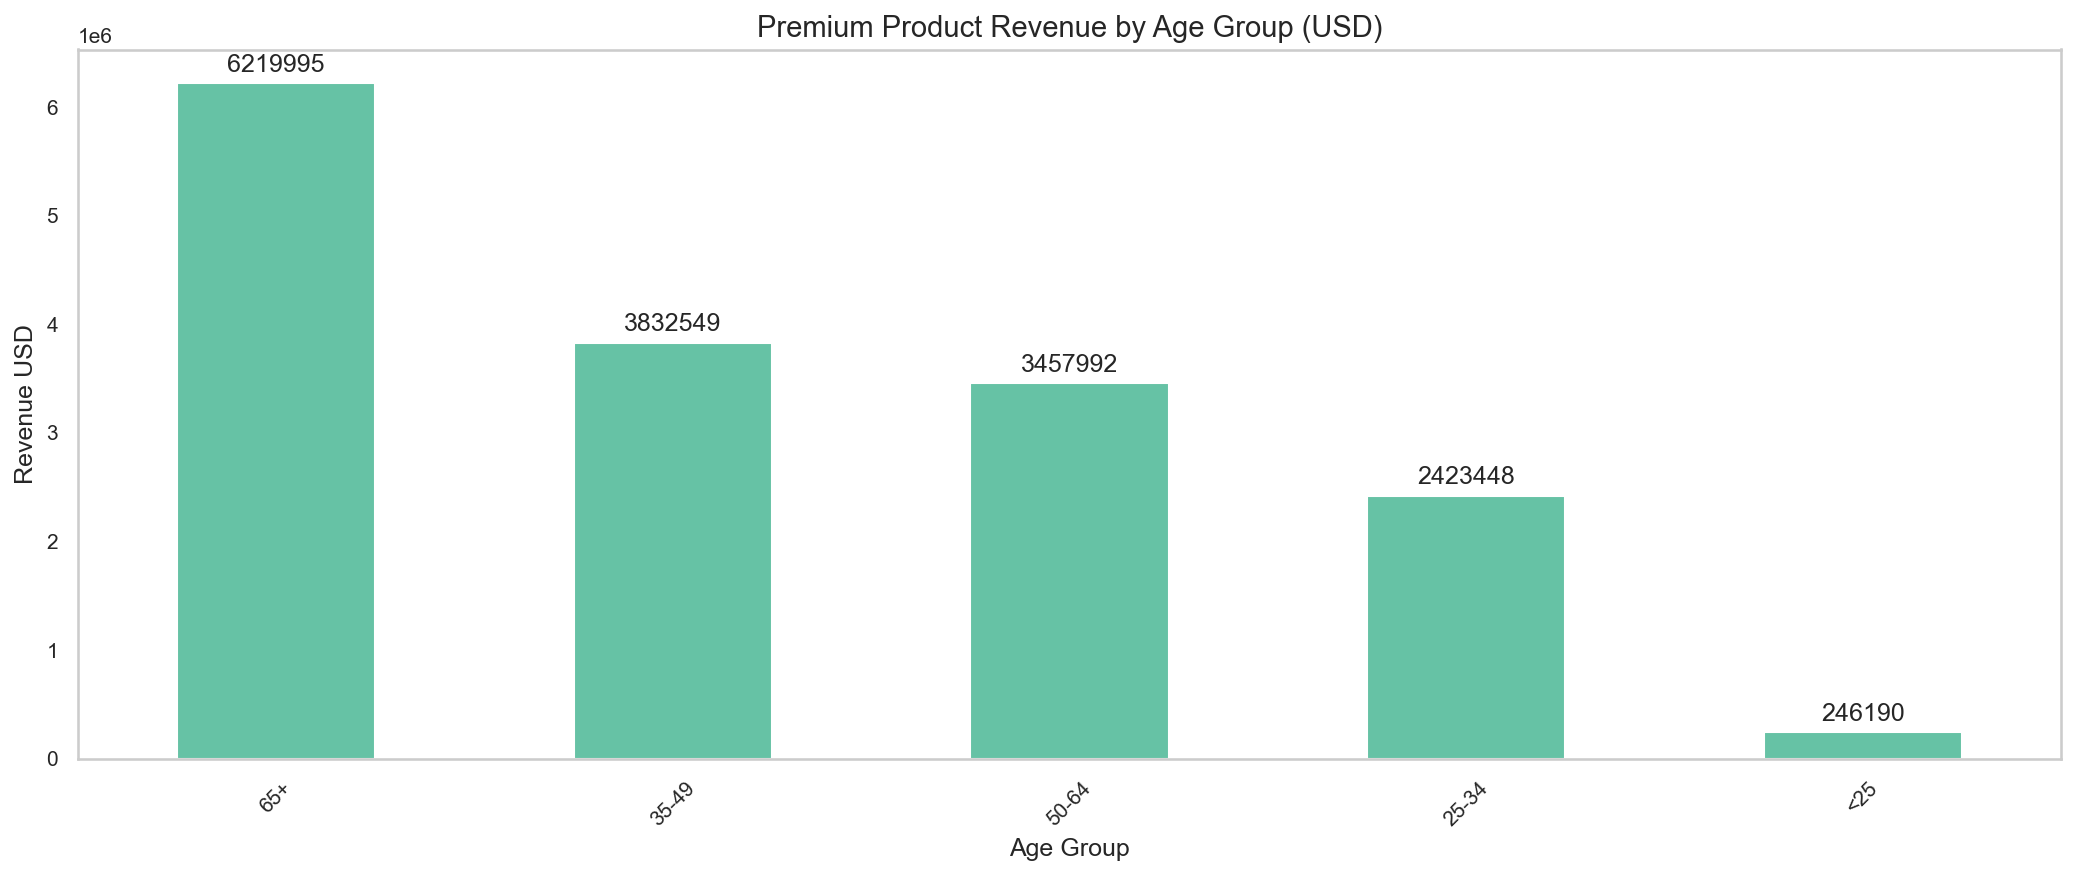

In [5]:
by_age = pm.premium_revenue_by_age_group(sales, products, customers)
display(by_age)
fig, ax = base.bar(
    by_age.set_index("Age Group")["Revenue USD"],
    title="Premium Product Revenue by Age Group (USD)",
    xlabel="Age Group", ylabel="Revenue USD",
    filename="premium_by_age_group.png"
)

display(fig)

## Premium Revenue by Channel

,Channel,Revenue USD
0,In-Store,13011289.67
1,Online,3168884.38


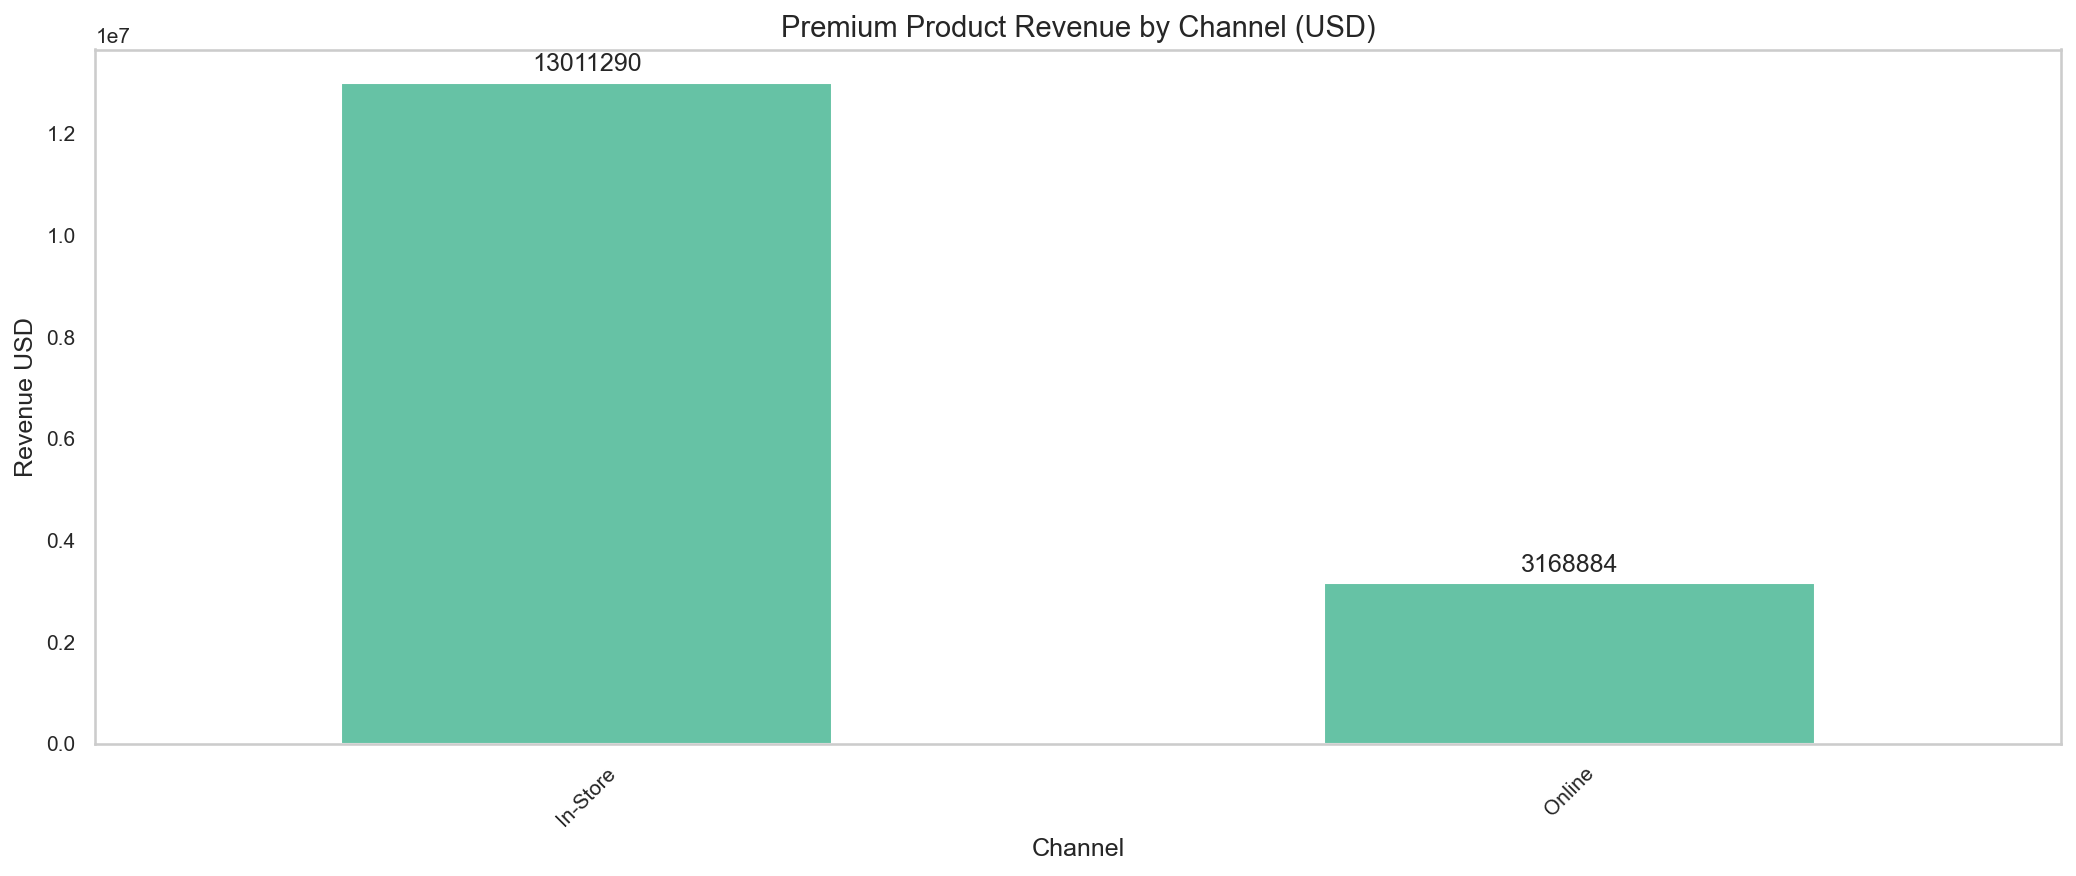

In [6]:
by_channel = pm.premium_revenue_by_channel(sales, products)
display(by_channel)
fig, ax = base.bar(
    by_channel.set_index("Channel")["Revenue USD"],
    title="Premium Product Revenue by Channel (USD)",
    xlabel="Channel", ylabel="Revenue USD",
    filename="premium_by_channel.png"
)

display(fig)

## Premium vs Standard Revenue by Category

In [7]:
vs_cat = pm.premium_vs_standard_by_category(sales, products)
display(vs_cat)

Segment,Premium,Standard
Category,,
Audio,0.00,3271311.85
Cameras and camcorders,1807125.30,4887287.42
Cell phones,0.00,6394703.50
Computers,5606233.36,14320077.50
Games and Toys,0.00,747540.88
Home Appliances,5333621.89,5788319.83
"Music, Movies and Audio Books",0.00,3227529.10
TV and Video,3433193.50,2714394.33


## Premium Product Analysis — Findings

### Overall
- Premium products (7.95% of catalogue, 200 SKUs) generated $16.2M — 28% of total revenue.
- Only 4 categories have premium products — Computers, Home Appliances, TV and Video, Cameras.
- Computers ($5.6M) and Home Appliances ($5.3M) are nearly equal at the top.

### Who Buys Premium
- 65+ drives $6.2M of premium revenue — the same dominance as overall revenue.
- The premium buyer profile mirrors the overall customer profile exactly — no distinct premium segment.
- Under-25 contributes just $246K — negligible in both premium and overall.

### Where Premium Sells
- US accounts for $8.3M of premium revenue — 51% of all premium sales.
- UK second at $2.6M, Germany third at $1.8M.
- France ($471K) and Netherlands ($549K) are notably weak on premium despite reasonable store counts.

### Channel
- In-Store: $13M (80%) vs Online: $3.2M (20%) of premium revenue.
- Premium split mirrors the overall channel split exactly — customers buy premium the same way regardless of product tier.
- No evidence that premium products drive online browsing or vice versa.